# BirdCLEF+ 2026 — Phase 2b Training (Background Mixing)

Goal: produce `checkpoints/model_v4.pt` by adding **background mixing** to the
Phase 1 setup. Each clip during training gets, with probability 0.5, overlaid
with a random 5s background from the unlabeled soundscape pool.

```
training_input = clip_5s + α * background_5s    (α ∈ [0.3, 0.8])
training_label = clip's primary + secondary species (unchanged)
```

This synthesizes training examples that combine clean species signal (from clips)
with realistic test ambience (from soundscapes) — closing the train/test acoustic
gap without changing labels.

**Setup compared to Phase 2a (the regression)**:
- `SOUNDSCAPE_REPLICAS = 10` (reverted from 4 — Phase 2a showed less replicas hurt LB).
- **No SpecAugment** (isolated the variable; will re-test on its own later).
- Multi-hot labels with `secondary_labels` (kept from Phase 1).
- New: background mixing.

Standalone-runnable top to bottom. Earlier phases live in git history.


## 1. Imports & device


In [15]:
import os, ast, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset

import librosa
import soundfile as sf
import timm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE, "  Torch:", torch.__version__)


Device: mps   Torch: 2.12.0


## 2. Configuration


In [16]:
PROJECT_ROOT  = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR      = PROJECT_ROOT / "data" / "birdclef-2026"
TRAIN_CSV     = DATA_DIR / "train.csv"
TRAIN_AUDIO   = DATA_DIR / "train_audio"
SS_AUDIO_DIR  = DATA_DIR / "train_soundscapes"
SS_LABELS_CSV = DATA_DIR / "train_soundscapes_labels.csv"
CKPT_DIR      = PROJECT_ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

assert TRAIN_CSV.exists() and SS_AUDIO_DIR.exists() and SS_LABELS_CSV.exists()

# Audio (must match inference)
SR          = 32000
CLIP_SEC    = 5
N_SAMPLES   = SR * CLIP_SEC
N_MELS      = 128
N_FFT       = 2048
HOP_LENGTH  = 512
FMIN, FMAX  = 20, 16000

# Training
BATCH_SIZE          = 32
EPOCHS              = 8
LR                  = 1e-3
NUM_WORKERS         = 0
SEED                = 42
BACKBONE            = "efficientnet_b0"
SOUNDSCAPE_REPLICAS = 10                  # reverted to Phase 1's value (Phase 2a's 4 hurt LB)

# Background mixing (new in Phase 2b)
BG_MIX_PROB         = 0.5                 # fraction of clip training examples that get a background overlay
BG_ALPHA_RANGE      = (0.3, 0.8)          # how loud the background is relative to the clip
BG_CACHE_SIZE       = 256                 # number of 5s backgrounds pre-cached in memory

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f"REPLICAS={SOUNDSCAPE_REPLICAS}  BG_MIX_PROB={BG_MIX_PROB}  BG_ALPHA={BG_ALPHA_RANGE}")


REPLICAS=10  BG_MIX_PROB=0.5  BG_ALPHA=(0.3, 0.8)


## 3. Load metadata + species mapping


In [17]:
df = pd.read_csv(TRAIN_CSV)
df["primary_label"] = df["primary_label"].astype(str)

species      = sorted(df["primary_label"].unique())
label_to_idx = {s: i for i, s in enumerate(species)}
NUM_CLASSES  = len(species)
print(f"Clips: {len(df):,}   Species: {NUM_CLASSES}")


Clips: 35,549   Species: 206


## 4. Audio helpers


In [18]:
def load_audio(path):
    wav, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    if sr != SR:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=SR)
    return wav.astype(np.float32)


def take_random_5s(wav):
    if len(wav) < N_SAMPLES:
        wav = np.pad(wav, (0, N_SAMPLES - len(wav)))
    elif len(wav) > N_SAMPLES:
        start = np.random.randint(0, len(wav) - N_SAMPLES + 1)
        wav = wav[start:start + N_SAMPLES]
    return wav


def wav_to_mel(wav):
    mel    = librosa.feature.melspectrogram(
        y=wav, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0,
    )
    mel_db = librosa.power_to_db(mel, top_db=80)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    return mel_db.astype(np.float32)


## 5. Metric + train/validate functions


In [19]:
def macro_auc(y_true, y_pred):
    scores = []
    for c in range(y_true.shape[1]):
        col = y_true[:, c]
        if col.sum() == 0 or col.sum() == len(col):
            continue
        try:
            scores.append(roc_auc_score(col, y_pred[:, c]))
        except ValueError:
            continue
    return float(np.mean(scores)) if scores else float("nan")


def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total, n = 0.0, 0
    pbar = tqdm(loader, desc="train", leave=False)
    for mel, label in pbar:
        mel, label = mel.to(DEVICE), label.to(DEVICE)
        optimizer.zero_grad()
        logits = model(mel)
        loss   = loss_fn(logits, label)
        loss.backward()
        optimizer.step()
        total += loss.item(); n += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total / max(1, n)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for mel, label in tqdm(loader, desc="val", leave=False):
        logits = model(mel.to(DEVICE)).cpu().numpy()
        all_logits.append(logits); all_labels.append(label.numpy())
    y_pred = np.concatenate(all_logits)
    y_true = np.concatenate(all_labels)
    y_prob = 1.0 / (1.0 + np.exp(-y_pred))
    return macro_auc(y_true, y_prob)


## 6. Soundscape labels + file-based train/val split


In [20]:
def parse_time_to_sec(s):
    h, m, ss = s.split(":")
    return int(h) * 3600 + int(m) * 60 + int(ss)

ss_df = pd.read_csv(SS_LABELS_CSV)
ss_df["start_sec"] = ss_df["start"].apply(parse_time_to_sec)
ss_df["end_sec"]   = ss_df["end"].apply(parse_time_to_sec)

unique_files = sorted(ss_df["filename"].unique())
shuffled     = np.random.default_rng(SEED).permutation(unique_files)
n_val_files  = max(1, int(len(shuffled) * 0.3))
val_files    = set(shuffled[:n_val_files])
ss_train_df  = ss_df[~ss_df["filename"].isin(val_files)].reset_index(drop=True)
ss_val_df    = ss_df[ ss_df["filename"].isin(val_files)].reset_index(drop=True)

# Files that are labeled (in either train or val) — exclude these from the
# background pool so we don't leak val signal through ambience.
LABELED_FILES = set(unique_files)
print(f"Labeled soundscape files: {len(LABELED_FILES)}  "
      f"({len(unique_files)-n_val_files} train, {n_val_files} val)")


Labeled soundscape files: 66  (47 train, 19 val)


## 7. Background cache from unlabeled soundscapes

We pre-cache `BG_CACHE_SIZE` random 5-second segments from random *unlabeled*
soundscape files. Reading from disk inside `__getitem__` would be too slow;
loading into memory once (~80 MB) makes background mixing essentially free during
training.

Why only unlabeled files: ~10,500 of 10,658 soundscape files have no label. Plenty
to draw from, and using them avoids leaking label signal from the val files.


In [21]:
# All soundscape files minus the labeled ones = unlabeled pool.
all_ss_files       = list(SS_AUDIO_DIR.glob("*.ogg"))
unlabeled_ss_files = [p for p in all_ss_files if p.name not in LABELED_FILES]
print(f"Soundscape pool: {len(unlabeled_ss_files):,} unlabeled files available for backgrounds")

# Pre-cache BG_CACHE_SIZE random 5s segments (~80 MB total at float32).
rng_bg = np.random.default_rng(SEED + 1)
print(f"Pre-caching {BG_CACHE_SIZE} background segments...")
background_cache = []
sampled_files = rng_bg.choice(len(unlabeled_ss_files), size=BG_CACHE_SIZE, replace=False)
for idx in tqdm(sampled_files, desc="caching"):
    path = unlabeled_ss_files[idx]
    try:
        wav = load_audio(path)
        wav = take_random_5s(wav)
        background_cache.append(wav)
    except Exception as e:
        print(f"[skip] {path.name}: {e}")
background_cache = np.stack(background_cache)
print(f"Cache shape: {background_cache.shape}  ({background_cache.nbytes/1e6:.1f} MB)")


def sample_background():
    """Return a random 5-second background waveform from the cache."""
    idx = np.random.randint(len(background_cache))
    return background_cache[idx]


Soundscape pool: 10,592 unlabeled files available for backgrounds
Pre-caching 256 background segments...


caching:   0%|          | 0/256 [00:00<?, ?it/s]

Cache shape: (256, 160000)  (163.8 MB)


## 8. Soundscape validation dataset

Same as Phase 1/2a: read the exact 5s window from a labeled soundscape, return
multi-hot label. This is our LB proxy (with known limitations — small val set,
related to train files).


In [22]:
class SoundscapeValDataset(Dataset):
    def __init__(self, df, label_to_idx, num_classes):
        self.df = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.num_classes  = num_classes

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row   = self.df.iloc[i]
        path  = SS_AUDIO_DIR / row["filename"]
        start = row["start_sec"]; end = row["end_sec"]
        try:
            wav = load_audio(path)
        except Exception as e:
            print(f"[warn] failed to load {path}: {e}")
            wav = np.zeros(N_SAMPLES, dtype=np.float32)
        start_samp, end_samp = start * SR, end * SR
        if len(wav) < end_samp:
            wav = np.pad(wav, (0, end_samp - len(wav)))
        chunk = wav[start_samp:end_samp]
        if len(chunk) < N_SAMPLES: chunk = np.pad(chunk, (0, N_SAMPLES - len(chunk)))
        elif len(chunk) > N_SAMPLES: chunk = chunk[:N_SAMPLES]

        mel = wav_to_mel(chunk)
        mel = torch.from_numpy(mel).unsqueeze(0)

        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for sp in str(row["primary_label"]).split(";"):
            sp = sp.strip()
            if sp in self.label_to_idx:
                label[self.label_to_idx[sp]] = 1.0
        return mel, label


ss_val_ds     = SoundscapeValDataset(ss_val_df, label_to_idx, NUM_CLASSES)
ss_val_loader = DataLoader(ss_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Val loader: {len(ss_val_loader)} batches, {len(ss_val_ds)} windows")


Val loader: 14 batches, 422 windows


## 9. Baseline — measure the Phase 1 checkpoint

Re-evaluate the strongest prior model (`model_v2.pt` from Phase 1) on this val
loader. This is the number to beat.


In [23]:
for cand in ["model_v3.pt", "model_v2.pt", "model.pt"]:
    baseline_ckpt_path = CKPT_DIR / cand
    if baseline_ckpt_path.exists():
        break
else:
    raise FileNotFoundError("No prior checkpoint found")

ckpt = torch.load(baseline_ckpt_path, map_location=DEVICE, weights_only=False)
eval_model = timm.create_model(
    ckpt["backbone"], pretrained=False, in_chans=1, num_classes=ckpt["num_classes"]
).to(DEVICE)
eval_model.load_state_dict(ckpt["state_dict"])
eval_model.eval()
baseline_ss_auc = validate(eval_model, ss_val_loader)
print(f"Baseline ({baseline_ckpt_path.name}) ss_val_auc: {baseline_ss_auc:.4f}")
del eval_model


val:   0%|          | 0/14 [00:00<?, ?it/s]

Baseline (model_v3.pt) ss_val_auc: 0.9057


## 10. Training datasets (with background mixing in BirdDataset)

`BirdDataset` now takes a `bg_mix_prob` argument. When triggered, it:
1. Samples a random background from `background_cache`.
2. Randomly scales the background by `α ∈ [0.3, 0.8]`.
3. Adds it to the clip.
4. Renormalizes to prevent clipping (audio values must stay in roughly [-1, 1]).
5. Label stays unchanged — the species call is still there, just embedded in ambience.

`SoundscapeTrainDataset` is unchanged from Phase 1 — soundscape windows already
contain realistic ambience, so we don't add more.


In [24]:
def parse_secondary_labels(s):
    if pd.isna(s) or s in ("", "[]"):
        return []
    try:
        return list(ast.literal_eval(s))
    except (ValueError, SyntaxError):
        return []


class BirdDataset(Dataset):
    def __init__(self, df, label_to_idx, num_classes, training=True,
                 bg_mix_prob=0.0, bg_alpha_range=(0.3, 0.8)):
        self.df            = df.reset_index(drop=True)
        self.label_to_idx  = label_to_idx
        self.num_classes   = num_classes
        self.training      = training
        self.bg_mix_prob   = bg_mix_prob if training else 0.0
        self.bg_alpha_range = bg_alpha_range

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row  = self.df.iloc[i]
        path = TRAIN_AUDIO / row["filename"]
        try:
            wav = load_audio(path)
        except Exception as e:
            print(f"[warn] failed to load {path}: {e}")
            wav = np.zeros(N_SAMPLES, dtype=np.float32)
        wav = take_random_5s(wav)

        # ---- Background mixing ----
        if self.bg_mix_prob > 0 and np.random.random() < self.bg_mix_prob:
            bg    = sample_background()
            alpha = np.random.uniform(*self.bg_alpha_range)
            wav   = wav + alpha * bg
            # Renormalize so the mixed waveform stays in ~[-1, 1]
            peak = np.abs(wav).max()
            if peak > 1.0:
                wav = wav / peak
            wav = wav.astype(np.float32)

        mel = wav_to_mel(wav)
        mel = torch.from_numpy(mel).unsqueeze(0)

        # Multi-hot label
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        label[self.label_to_idx[row["primary_label"]]] = 1.0
        for sp in parse_secondary_labels(row.get("secondary_labels", "[]")):
            sp = str(sp)
            if sp in self.label_to_idx:
                label[self.label_to_idx[sp]] = 1.0
        return mel, label


class SoundscapeTrainDataset(Dataset):
    def __init__(self, df, label_to_idx, num_classes, gain_range=(0.7, 1.3)):
        self.df           = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.num_classes  = num_classes
        self.gain_range   = gain_range

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row   = self.df.iloc[i]
        path  = SS_AUDIO_DIR / row["filename"]
        start = row["start_sec"]; end = row["end_sec"]
        try:
            wav = load_audio(path)
        except Exception as e:
            print(f"[warn] failed to load {path}: {e}")
            wav = np.zeros(N_SAMPLES, dtype=np.float32)
        start_samp, end_samp = start * SR, end * SR
        if len(wav) < end_samp:
            wav = np.pad(wav, (0, end_samp - len(wav)))
        chunk = wav[start_samp:end_samp]
        if len(chunk) < N_SAMPLES: chunk = np.pad(chunk, (0, N_SAMPLES - len(chunk)))
        elif len(chunk) > N_SAMPLES: chunk = chunk[:N_SAMPLES]

        gain  = np.random.uniform(*self.gain_range)
        chunk = (chunk * gain).astype(np.float32)
        mel = wav_to_mel(chunk)
        mel = torch.from_numpy(mel).unsqueeze(0)

        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for sp in str(row["primary_label"]).split(";"):
            sp = sp.strip()
            if sp in self.label_to_idx:
                label[self.label_to_idx[sp]] = 1.0
        return mel, label


## 11. Sanity check — visualize a mixed example

Compare clean clip mel vs background-mixed mel for the same clip. You should see
similar "structure" (the bird call) on both, but the mixed version will have
visible ambient texture across the whole spectrogram.


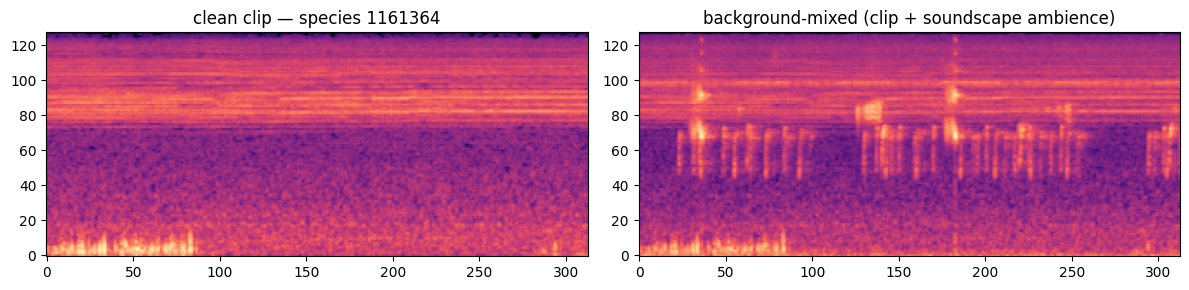

In [25]:
# Build a tiny dataset, get clean and mixed versions of the same clip.
_probe_df = df[["filename", "primary_label", "secondary_labels"]].head(1)
_ds_clean = BirdDataset(_probe_df, label_to_idx, NUM_CLASSES, training=False, bg_mix_prob=0.0)
_ds_mixed = BirdDataset(_probe_df, label_to_idx, NUM_CLASSES, training=True,  bg_mix_prob=1.0)

np.random.seed(123)
_mel_clean, _ = _ds_clean[0]
np.random.seed(123)
_mel_mixed, _ = _ds_mixed[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].imshow(_mel_clean[0].numpy(), origin="lower", aspect="auto", cmap="magma")
axes[0].set_title(f"clean clip — species {_probe_df.iloc[0]['primary_label']}")
axes[1].imshow(_mel_mixed[0].numpy(), origin="lower", aspect="auto", cmap="magma")
axes[1].set_title("background-mixed (clip + soundscape ambience)")
plt.tight_layout(); plt.show()


## 12. Mixed DataLoader

`REPLICAS = 10` (reverted from Phase 2a's 4). Soundscape windows still ~22% of
each epoch. Difference vs Phase 1: clips have a 50% chance of getting a
background mixed in.


In [26]:
df_train_csv = pd.read_csv(TRAIN_CSV)
df_train_csv["primary_label"] = df_train_csv["primary_label"].astype(str)
df_train_csv = df_train_csv[df_train_csv["primary_label"].isin(label_to_idx)].reset_index(drop=True)

counts        = df_train_csv["primary_label"].value_counts()
rare_species  = counts[counts < 2].index
rare_rows     = df_train_csv[df_train_csv["primary_label"].isin(rare_species)]
splittable    = df_train_csv[~df_train_csv["primary_label"].isin(rare_species)]
clip_train_df, _ = train_test_split(
    splittable, test_size=0.15, random_state=SEED, stratify=splittable["primary_label"],
)
clip_train_df = pd.concat([clip_train_df, rare_rows], ignore_index=True)

clip_train_ds = BirdDataset(clip_train_df, label_to_idx, NUM_CLASSES,
                            training=True, bg_mix_prob=BG_MIX_PROB,
                            bg_alpha_range=BG_ALPHA_RANGE)
ss_train_ds   = SoundscapeTrainDataset(ss_train_df, label_to_idx, NUM_CLASSES)
ss_train_rep  = ConcatDataset([ss_train_ds] * SOUNDSCAPE_REPLICAS)
mixed_train_ds = ConcatDataset([clip_train_ds, ss_train_rep])

mixed_train_loader = DataLoader(
    mixed_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
)
print(f"Mix: {len(clip_train_ds):,} clips (BG mix p={BG_MIX_PROB}) "
      f"+ {len(ss_train_ds)}×{SOUNDSCAPE_REPLICAS} soundscapes "
      f"= {len(mixed_train_ds):,} total")
print(f"Batches per epoch: {len(mixed_train_loader)}")


Mix: 30,217 clips (BG mix p=0.5) + 1056×10 soundscapes = 40,777 total
Batches per epoch: 1275


## 13. Train and save `model_v4.pt`

Same architecture (efficientnet_b0). Checkpoint selection by soundscape val.

Expected wall-clock: ~3 hours on Apple Silicon MPS.

Loss should be *slightly higher* than Phase 1 at the same epoch (because the model
sees more diverse inputs and can't memorize as easily). Soundscape val should be
similar to or better than Phase 1's 0.882. **The LB is what we really care about** —
local val is a sanity check, not a tuning target.


In [27]:
PHASE2B_EPOCHS = 8
PHASE2B_LR     = 1e-3

model_v4     = timm.create_model(BACKBONE, pretrained=True, in_chans=1, num_classes=NUM_CLASSES).to(DEVICE)
optimizer_v4 = torch.optim.Adam(model_v4.parameters(), lr=PHASE2B_LR)
loss_fn      = nn.BCEWithLogitsLoss()

best_ss_auc = -1.0
ckpt_v4     = CKPT_DIR / "model_v4.pt"

for epoch in range(1, PHASE2B_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model_v4, mixed_train_loader, optimizer_v4, loss_fn)
    ss_auc     = validate(model_v4, ss_val_loader)
    dt         = time.time() - t0

    flag = ""
    if ss_auc > best_ss_auc:
        best_ss_auc = ss_auc
        torch.save({
            "state_dict":   model_v4.state_dict(),
            "species":      species,
            "label_to_idx": label_to_idx,
            "backbone":     BACKBONE,
            "num_classes":  NUM_CLASSES,
            "sr":           SR, "n_mels": N_MELS, "n_fft": N_FFT,
            "hop_length":   HOP_LENGTH, "fmin": FMIN, "fmax": FMAX,
            "clip_sec":     CLIP_SEC,
        }, ckpt_v4)
        flag = "  <- new best, saved"
    print(f"Epoch {epoch:2d}/{PHASE2B_EPOCHS}  loss={train_loss:.4f}  "
          f"ss_val_auc={ss_auc:.4f}  ({dt:.1f}s){flag}")

print(f"\nBaseline ({baseline_ckpt_path.name}) ss_val_auc: {baseline_ss_auc:.4f}  (Phase 1 LB: 0.772)")
print(f"Phase 2b  (model_v4.pt)       ss_val_auc: {best_ss_auc:.4f}")
print(f"Δ ss_val_auc:                              {best_ss_auc - baseline_ss_auc:+.4f}")


train:   0%|          | 0/1275 [00:00<?, ?it/s]

val:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  1/8  loss=0.0274  ss_val_auc=0.8772  (1534.8s)  <- new best, saved


train:   0%|          | 0/1275 [00:00<?, ?it/s]

val:   0%|          | 0/14 [00:00<?, ?it/s]

...

train:   0%|          | 0/1275 [00:00<?, ?it/s]

val:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  3/8  loss=0.0162  ss_val_auc=0.8298  (19304.5s)


train:   0%|          | 0/1275 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 14. What's next

When training finishes:

- I'll handle the Kaggle dataset v5 + kernel v7 + auto-submit.
- LB target: **0.79-0.83**. Background mixing on top of Phase 1's setup should
  bridge the train/test acoustic gap that's been hurting us.
- If LB > 0.78, we've genuinely improved. Next is Phase 2c (SpecAugment isolated,
  on top of this) or Phase 3 (Perch).
- If LB < 0.77, background mixing didn't help. We diagnose and try a different
  Phase 2 lever.

Drop the LB number when it lands and we'll plan from there.
